In [1]:

import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")

df = pd.read_csv("sonardataset.csv")

print("Shape :", df.shape)
print("\n")

df.head()

Shape : (208, 61)




,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60,Y
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


In [2]:

df.info()

print("\nMissing Values:\n")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 61 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x_1     208 non-null    float64
 1   x_2     208 non-null    float64
 2   x_3     208 non-null    float64
 3   x_4     208 non-null    float64
 4   x_5     208 non-null    float64
 5   x_6     208 non-null    float64
 6   x_7     208 non-null    float64
 7   x_8     208 non-null    float64
 8   x_9     208 non-null    float64
 9   x_10    208 non-null    float64
 10  x_11    208 non-null    float64
 11  x_12    208 non-null    float64
 12  x_13    208 non-null    float64
 13  x_14    208 non-null    float64
 14  x_15    208 non-null    float64
 15  x_16    208 non-null    float64
 16  x_17    208 non-null    float64
 17  x_18    208 non-null    float64
 18  x_19    208 non-null    float64
 19  x_20    208 non-null    float64
 20  x_21    208 non-null    float64
 21  x_22    208 non-null    float64
 22  x_

In [3]:
# Class distribution

print(df.iloc[:, -1].value_counts())

Y
M    111
R     97
Name: count, dtype: int64


In [4]:
# Separate features and target

X = df.drop("Y", axis=1)

y = df["Y"]

print(X.shape)
print(y.shape)

(208, 60)
(208,)


In [5]:
# Convert target labels into numbers

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(y)

print(y[:10])

[1 1 1 1 1 1 1 1 1 1]


In [6]:
# Normalize data

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(X)

print(X.shape)

(208, 60)


In [7]:
# Split data into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train :", X_train.shape)
print("X_test :", X_test.shape)

print("y_train :", y_train.shape)
print("y_test :", y_test.shape)

X_train : (166, 60)
X_test : (42, 60)
y_train : (166,)
y_test : (42,)


In [8]:
# Build Basic ANN Model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

# Hidden Layer
model.add(Dense(
    16,
    activation='relu',
    input_shape=(60,)
))

# Output Layer
model.add(Dense(
    1,
    activation='sigmoid'
))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 993 (3.88 KB)

 Trainable params: 993 (3.88 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Train ANN

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5000 - loss: 0.7672 - val_accuracy: 0.4412 - val_loss: 0.8483
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5758 - loss: 0.6934 - val_accuracy: 0.5000 - val_loss: 0.8009
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6439 - loss: 0.6349 - val_accuracy: 0.5882 - val_loss: 0.7625
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6742 - loss: 0.5909 - val_accuracy: 0.5882 - val_loss: 0.7297
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7197 - loss: 0.5494 - val_accuracy: 0.6471 - val_loss: 0.7051
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7576 - loss: 0.5185 - val_accuracy: 0.6765 - val_loss: 0.6845
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7879 - loss: 0.4889 - val_accuracy: 0.6765 - val_loss: 0.6648
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7955 - loss: 0.4636 - val_accuracy: 0.7059 - val_loss: 0.6492

In [10]:
# Predict on test data

y_pred = model.predict(X_test)

# Convert probabilities into 0 and 1

y_pred = (y_pred > 0.5).astype(int)

# Evaluation Metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Accuracy : 0.8095238095238095
Precision : 0.7
Recall : 0.875
F1 Score : 0.7777777777777778


In [11]:
tuned_model = Sequential()

tuned_model.add(Dense(
    32,
    activation='relu',
    input_shape=(60,)
))

tuned_model.add(Dense(
    16,
    activation='relu'
))

tuned_model.add(Dense(
    1,
    activation='sigmoid'
))

tuned_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

tuned_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 32)             │         1,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,497 (9.75 KB)

 Trainable params: 2,497 (9.75 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Train Tuned ANN

history_tuned = tuned_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.4167 - loss: 0.7564 - val_accuracy: 0.4706 - val_loss: 0.6702
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5606 - loss: 0.6569 - val_accuracy: 0.5588 - val_loss: 0.6260
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6667 - loss: 0.5942 - val_accuracy: 0.6471 - val_loss: 0.5948
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7121 - loss: 0.5470 - val_accuracy: 0.7353 - val_loss: 0.5700
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7424 - loss: 0.5078 - val_accuracy: 0.7647 - val_loss: 0.5529
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7955 - loss: 0.4722 - val_accuracy: 0.7353 - val_loss: 0.5356
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8182 - loss: 0.4438 - val_accuracy: 0.7353 - val_loss: 0.5184
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8409 - loss: 0.4153 - val_accuracy: 0.7647 - val_loss: 0.5043
Epoch 9

In [13]:
# Predictions from Tuned ANN

y_pred_tuned = tuned_model.predict(X_test)

y_pred_tuned = (y_pred_tuned > 0.5).astype(int)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_tuned))
print("Precision :", precision_score(y_test, y_pred_tuned))
print("Recall :", recall_score(y_test, y_pred_tuned))
print("F1 Score :", f1_score(y_test, y_pred_tuned))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
Accuracy : 0.8333333333333334
Precision : 0.7142857142857143
Recall : 0.9375
F1 Score : 0.8108108108108109


In [14]:
# Tune Activation Function and Learning Rate

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

model_tuned2 = Sequential()

model_tuned2.add(
    Dense(
        32,
        activation='tanh',
        input_shape=(60,)
    )
)

model_tuned2.add(
    Dense(
        16,
        activation='tanh'
    )
)

model_tuned2.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

optimizer = Adam(
    learning_rate=0.001
)

model_tuned2.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_tuned2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 32)             │         1,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,497 (9.75 KB)

 Trainable params: 2,497 (9.75 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Train Tuned Model

history_tuned2 = model_tuned2.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.4773 - loss: 0.8072 - val_accuracy: 0.6471 - val_loss: 0.6784
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5833 - loss: 0.6462 - val_accuracy: 0.7353 - val_loss: 0.5965
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7348 - loss: 0.5626 - val_accuracy: 0.7941 - val_loss: 0.5540
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7803 - loss: 0.5125 - val_accuracy: 0.8235 - val_loss: 0.5304
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7803 - loss: 0.4735 - val_accuracy: 0.8235 - val_loss: 0.5108
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8182 - loss: 0.4401 - val_accuracy: 0.8529 - val_loss: 0.4930
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8409 - loss: 0.4123 - val_accuracy: 0.8235 - val_loss: 0.4838
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8561 - loss: 0.3890 - val_accuracy: 0.7941 - val_loss: 0.4777
Epoch 

In [16]:
# Evaluate Tuned ANN 2

y_pred_tuned2 = model_tuned2.predict(X_test)

y_pred_tuned2 = (y_pred_tuned2 > 0.5).astype(int)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_tuned2))
print("Precision :", precision_score(y_test, y_pred_tuned2))
print("Recall :", recall_score(y_test, y_pred_tuned2))
print("F1 Score :", f1_score(y_test, y_pred_tuned2))

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
Accuracy : 0.7619047619047619
Precision : 0.625
Recall : 0.9375
F1 Score : 0.75


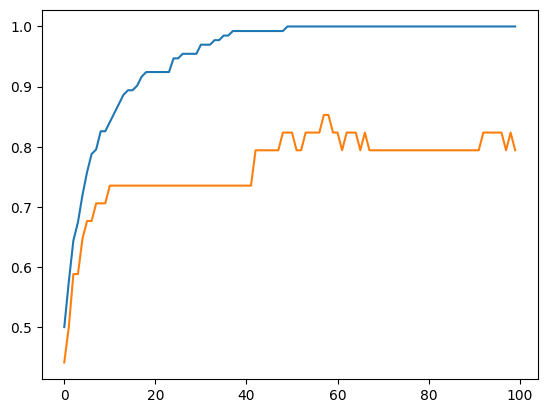

In [18]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

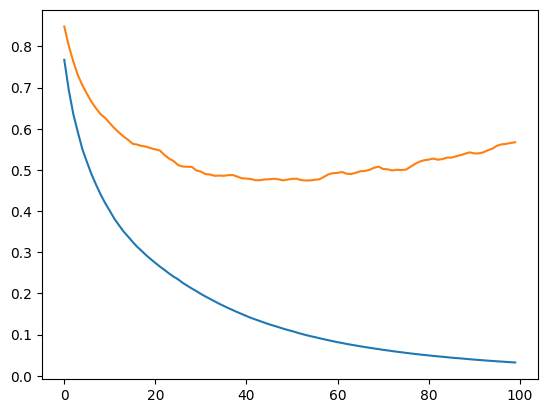

In [19]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

**1. Data Exploration and Preprocessing**



The Sonar dataset contains 208 records and 60 input features with 1 target column. The target variable contains two classes: Mine (M) and Rock (R).

The dataset was explored using shape(), info() and head(). Missing values were checked and no missing values were found.

The target variable was encoded into numerical form and feature scaling was performed using StandardScaler. The dataset was then divided into training and testing sets.

**2. Model Implementation**

An Artificial Neural Network (ANN) model was built using TensorFlow and Keras. The model contains input, hidden and output layers.

The model was trained using the training dataset and predictions were made on the testing dataset. The performance of the model was evaluated using different metrics.

**3. Hyperparameter Tuning**

To improve the model performance, different hyperparameters were tested such as hidden layers, number of neurons, activation functions and learning rate.

Different ANN models were trained and their performances were compared. The best performing model was selected based on the evaluation metrics.

**4. Evaluation Metrics**



The models were evaluated using Accuracy, Precision, Recall and F1-Score.

These metrics helped in measuring the performance of the ANN models and comparing different model configurations.

**5. Model Comparison**



The default ANN model achieved an accuracy of 80.95%.

The first tuned ANN model achieved the highest accuracy of 83.33% and performed better than the other models.

The second tuned ANN model achieved high recall but lower overall accuracy. Therefore, the first tuned ANN model was selected as the best model.

**6. Advantages and Limitations**

Default ANN Model

Advantages:

Simple and easy to train.

Provides good baseline performance.

Limitations:

Lower accuracy than the tuned model.

Tuned ANN Model 1

Advantages:

Best accuracy and overall performance.

Better classification results.

Limitations:

Slightly more complex than the default model.

Tuned ANN Model 2

Advantages:

High recall value.

Limitations:

Lower accuracy and precision.

**7. Conclusion**

In this assignment, ANN was used to classify sonar signals as mines or rocks.


After preprocessing and training the models, different hyperparameters were tested to improve performance.


Among all the models, the first tuned ANN model achieved the best results with an accuracy of 83.33%.


Therefore, the first tuned ANN model was selected as the final model.